# EDA - Do EVs actually cost less on fuel than Gas cars?

I wanted to look at this because there are alot of debate about whether EVs are actually cheaper to run and I figured fuel cost is a good starting point for comparison.

My Hypothesis for this project:
Null Hypothesis: Fuel has no real effect on annual fuel cost, any difference we see between gas and electric vehicles is just random.

Alternative hypothesis: Gas vehicles cost significantly more per year on fuel than electric vehicles.

Test statistics: Mean annual fuel cost for gas cars minus mean annual fuel cost for EVs

Significance level: 0.05

### Step 1 – Read and describe the data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
evgas = pd.read_csv("vehicles.csv",low_memory=False)

print(evgas.shape)
evgas[['year', 'make', 'model', 'VClass', 'fuelType1', 'fuelCost08']].head()

(49846, 84)


,year,make,model,VClass,fuelType1,fuelCost08
0,1985,Alfa Romeo,Spider Veloce 2000,Two Seaters,Regular Gasoline,2850
1,1985,Ferrari,Testarossa,Two Seaters,Regular Gasoline,5450
2,1985,Dodge,Charger,Subcompact Cars,Regular Gasoline,2200
3,1985,Dodge,B150/B250 Wagon 2WD,Vans,Regular Gasoline,5450
4,1993,Subaru,Legacy AWD Turbo,Compact Cars,Premium Gasoline,3650


In [2]:
evgas[['year', 'make', 'model', 'VClass', 'fuelType1', 'fuelCost08']].info()

<class 'pandas.DataFrame'>
RangeIndex: 49846 entries, 0 to 49845
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   year        49846 non-null  int64
 1   make        49846 non-null  str  
 2   model       49846 non-null  str  
 3   VClass      49846 non-null  str  
 4   fuelType1   49845 non-null  str  
 5   fuelCost08  49846 non-null  int64
dtypes: int64(2), str(4)
memory usage: 2.3 MB


In [3]:
evgas[['year', 'fuelCost08']].describe().round(2)

,year,fuelCost08
count,49846.00,49846.00
mean,2005.29,3199.34
std,13.03,959.05
min,1984.00,0.00
25%,1993.00,2600.00
50%,2006.00,3150.00
75%,2017.00,3750.00
max,2026.00,9900.00


In [4]:
missing = evgas[['year', 'make', 'model', 'VClass', 'fuelType1', 'fuelCost08']].isnull().sum()
print(missing)
print('missing:', missing.sum())

year          0
make          0
model         0
VClass        0
fuelType1     1
fuelCost08    0
dtype: int64
missing: 1


### Step 2 – Clean & Filter
* Check which variables have missing values and fill them so the dataset is complete.  
* Use the mean for numeric fields and the most common value (mode) for strings.  
* When you’re done, confirm that no missing values remain.

In [5]:
df = evgas.copy()

missing_before = df.isnull().sum()
print('columns with missing values')
print(missing_before[missing_before > 0])

columns with missing values
cylinders      1471
displ          1469
drive          1186
eng_dscr      18209
fuelType1         1
trany            11
guzzler       47013
trans_dscr    34802
tCharger      38314
sCharger      48702
atvType       43296
fuelType2     47838
rangeA        47842
evMotor       46399
mfrCode       30808
c240Dscr      49705
c240bDscr     49711
startStop     31689
dtype: int64


In [6]:
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())


str_cols = df.select_dtypes(include=['object', 'str']).columns
for col in str_cols:
    mode_val = df[col].mode()
    if not mode_val.empty:
        df[col] = df[col].fillna(mode_val[0])

print('missing after cleaning:', df.isnull().sum().sum())

missing after cleaning: 0


In [7]:
df = evgas.copy()

# Filtering year to 2015-2024, and only gas/electric vehicles
df = df[df['year'].between(2015, 2024)]
df = df[df['fuelType1'].isin(['Regular Gasoline', 'Premium Gasoline', 'Midgrade Gasoline', 'Electricity'])]
df = df[df['fuelCost08'].notna() & (df['fuelCost08'] > 0)]

# fuel category 
df['fuel_category'] = df['fuelType1'].apply(lambda x: 'Electric' if x == 'Electricity' else 'Gas')

# simplify vehicle class
def simplify_class(vclass):
    v = str(vclass).lower()
    if any(x in v for x in ['compact', 'small', 'minicompact', 'subcompact']):
        return 'Compact'
    elif any(x in v for x in ['midsize', 'mid-size']):
        return 'Midsize'
    elif any(x in v for x in ['suv', 'sport utility']):
        return 'SUV'
    elif any(x in v for x in ['truck', 'pickup']):
        return 'Truck'
    elif any(x in v for x in ['large', 'standard']):
        return 'Large'
    else:
        return 'Other'

df['class_simple'] = df['VClass'].apply(simplify_class)
df = df[df['class_simple'] != 'Other']
df = df.rename(columns={'fuelCost08': 'annual_fuel_cost'})

print(df['fuel_category'].value_counts())
print(df['class_simple'].value_counts())
print('total rows:', len(df))

fuel_category
Gas         10810
Electric      711
Name: count, dtype: int64
class_simple
Compact    6016
Midsize    1920
SUV        1674
Large      1070
Truck       841
Name: count, dtype: int64
total rows: 11521


### Step 3: EDA

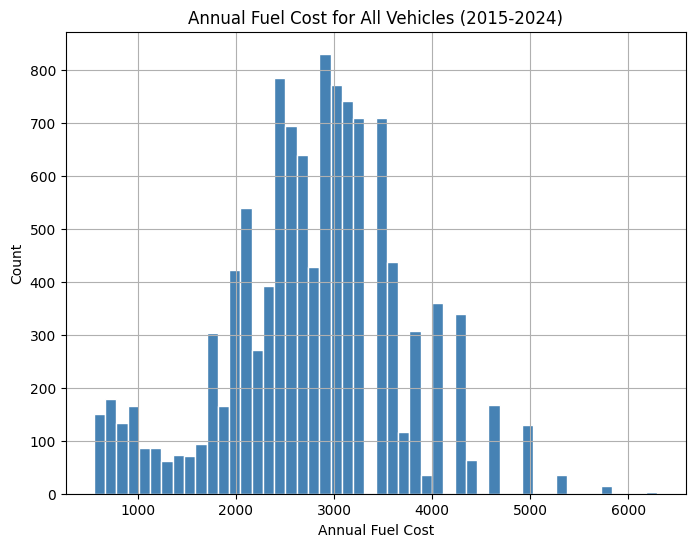

count    11521.00
mean      2791.27
std        904.04
min        550.00
25%       2300.00
50%       2850.00
75%       3300.00
max       6300.00
Name: annual_fuel_cost, dtype: float64


In [8]:
plt.figure(figsize=(8, 6))
df['annual_fuel_cost'].hist(bins=50, color='steelblue', edgecolor='white')
plt.title('Annual Fuel Cost for All Vehicles (2015-2024)')
plt.xlabel('Annual Fuel Cost')
plt.ylabel('Count')
plt.show()

print(df['annual_fuel_cost'].describe().round(2))

In [9]:
summary = df.groupby('fuel_category')['annual_fuel_cost'].agg(
    Count='count', Mean='mean', Median='median', Std='std', min='min', max='max'
).round(2)
print(summary)

               Count     Mean  Median     Std   min   max
fuel_category                                            
Electric         711   823.21   800.0  173.03   550  1600
Gas            10810  2920.71  2850.0  773.01  1000  6300


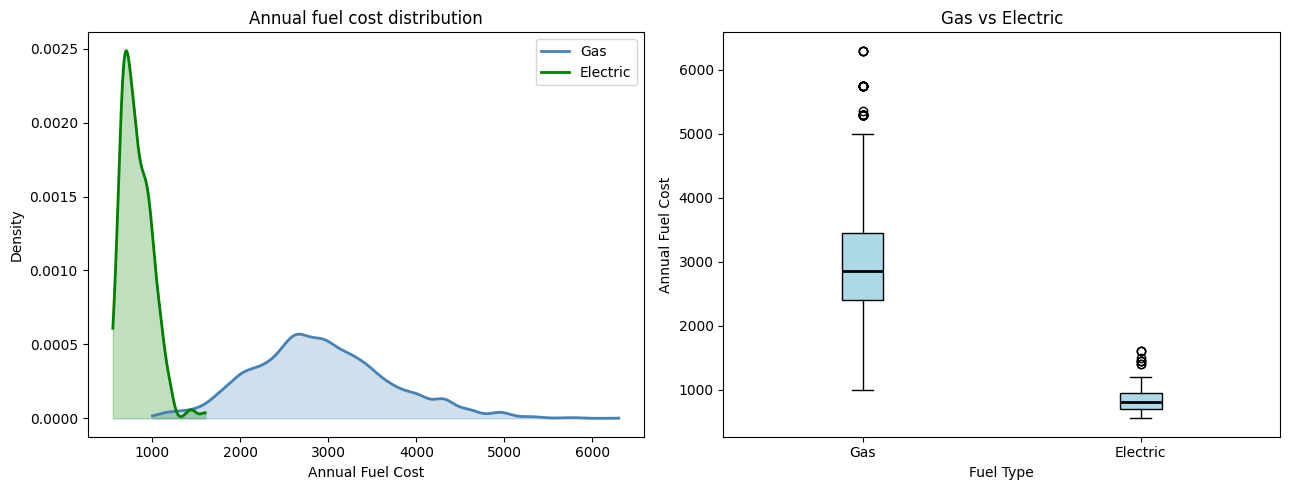

In [10]:
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 2, figsize=(13, 5))


ax = axes[0]

for label, color in [('Gas', 'steelblue'), ('Electric', 'green')]:
    vals = df[df['fuel_category'] == label]['annual_fuel_cost'].values
    kde = gaussian_kde(vals)
    x = np.linspace(vals.min(), vals.max(), 300)
    ax.plot(x, kde(x), color=color, linewidth=2, label=label)
    ax.fill_between(x, kde(x), alpha=0.25, color=color)
ax.set_title('Annual fuel cost distribution')
ax.set_xlabel('Annual Fuel Cost')
ax.set_ylabel('Density')
ax.legend()

ax2 = axes[1]
gas_vals = df[df['fuel_category'] == 'Gas']['annual_fuel_cost'].values
ev_vals  = df[df['fuel_category'] == 'Electric']['annual_fuel_cost'].values
ax2.boxplot([gas_vals, ev_vals], tick_labels=['Gas', 'Electric'],
            patch_artist=True,
            boxprops=dict(facecolor='lightblue'),
            medianprops=dict(color='black', linewidth=2))
ax2.set_title('Gas vs Electric')
ax2.set_xlabel('Fuel Type')
ax2.set_ylabel('Annual Fuel Cost')
plt.tight_layout()
plt.show()

In [11]:
print(df.groupby(['class_simple', 'fuel_category'])['annual_fuel_cost'].agg(
    count='count', mean='mean', median='median'
).round(2))

                            count     mean  median
class_simple fuel_category                        
Compact      Electric         279   767.38   750.0
             Gas             5737  2733.23  2700.0
Large        Electric         116   770.26   750.0
             Gas              954  3094.39  3150.0
Midsize      Electric         117   732.05   700.0
             Gas             1803  2634.19  2550.0
SUV          Electric         150   946.00   900.0
             Gas             1524  3582.94  3500.0
Truck        Electric          49  1108.16  1100.0
             Gas              792  3447.54  3300.0


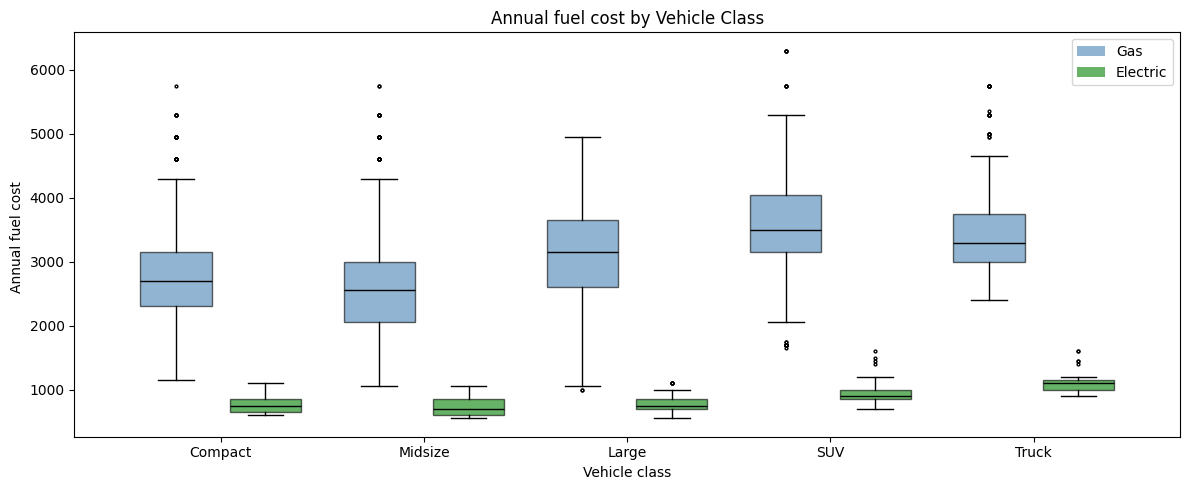

In [13]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(12, 5))

class_order = [c for c in ['Compact', 'Midsize', 'Large', 'SUV', 'Truck'] if c in df['class_simple'].unique()]

for label, color in [('Gas', 'steelblue'), ('Electric', 'green')]:
    subset = df[df['fuel_category'] == label]
    positions = [i + (0.22 if label == 'Electric' else -0.22) for i in range(len(class_order))]
    data = [subset[subset['class_simple'] == c]['annual_fuel_cost'].values for c in class_order]
    ax.boxplot(data, positions=positions, widths=0.35, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color='black'),
               flierprops=dict(markersize=2))

ax.set_xticks(range(len(class_order)))
ax.set_xticklabels(class_order)
ax.set_title('Annual fuel cost by Vehicle Class')
ax.set_xlabel('Vehicle class')
ax.set_ylabel('Annual fuel cost ')
legend_handles = [Patch(facecolor='steelblue', alpha=0.6, label='Gas'),
                  Patch(facecolor='green', alpha=0.6, label='Electric')]
ax.legend(handles=legend_handles)
plt.tight_layout()
plt.show()

### Step 4: Observed difference permutation test

In [14]:
ev  = df[df['fuel_category'] == 'Electric']['annual_fuel_cost'].values
gas = df[df['fuel_category'] == 'Gas']['annual_fuel_cost'].values

obs_diff = gas.mean() - ev.mean()
print(f'mean annual cost - gas:${gas.mean():,.2f}')
print(f'mean annual cost - ev: ${ev.mean():,.2f}')
print(f'observed difference: ${obs_diff:,.2f}')

mean annual cost - gas:$2,920.71
mean annual cost - ev: $823.21
observed difference: $2,097.51


In [15]:
n_perm = 10000
combined = np.concatenate([gas, ev])
n_gas = len(gas)  

perm_diffs = np.array([
    np.random.permutation(combined)[:n_gas].mean() -
    np.random.permutation(combined)[n_gas:].mean()
    for _ in range(n_perm)
])

p_value = np.mean(perm_diffs >= obs_diff)
print(f'p-value (one-tailed): {p_value:.4f}')


p-value (one-tailed): 0.0000


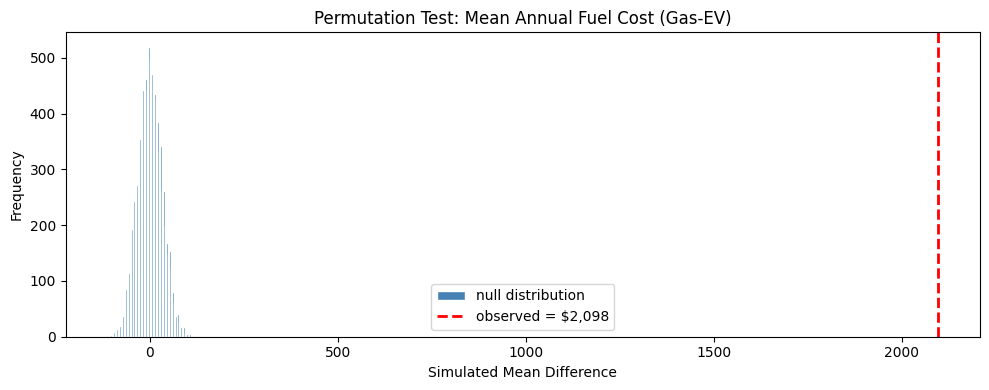

In [16]:
plt.figure(figsize=(10, 4))
plt.hist(perm_diffs, bins=60, color='steelblue', edgecolor='white', label='null distribution')
plt.axvline(obs_diff, color='red', linestyle='dashed', linewidth=2, label=f'observed = ${obs_diff:,.0f}')
plt.title('Permutation Test: Mean Annual Fuel Cost (Gas-EV)')
plt.xlabel('Simulated Mean Difference')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

### Step 5: bootstrap confidence intervals

Two metrics:
1. Mean Difference (Gas - EV): coulde use CLT here since samples are large but bootstrapping anyway to be consistent
2. Median per group: CLT doesnt apply to medians, especially with skewed data like this, so bootstrap is the right call.

In [17]:
BOOT = 10000

# mean difference
boot_mean_diffs = np.array([
    np.random.choice(gas, size=len(gas), replace=True).mean() -
    np.random.choice(ev,  size=len(ev),  replace=True).mean()
    for _ in range(BOOT)
])
ci_mean = np.percentile(boot_mean_diffs, [2.5, 97.5])

print('Mean difference (gas - EV)')
print(f'observed: ${obs_diff:,.2f}')
print(f'95% CI: (${ci_mean[0]:,.2f}, ${ci_mean[1]:,.2f})')

# Median per group
boot_med_gas = np.array([np.median(np.random.choice(gas, size=len(gas), replace=True)) for _ in range(BOOT)])
boot_med_ev  = np.array([np.median(np.random.choice(ev,  size=len(ev),  replace=True)) for _ in range(BOOT)])

ci_med_gas = np.percentile(boot_med_gas, [2.5, 97.5])
ci_med_ev  = np.percentile(boot_med_ev,  [2.5, 97.5])

print()
print('Median annual fuel cost')
print(f'  gas: ${np.median(gas):,.2f}, 95% CI: (${ci_med_gas[0]:,.2f}, ${ci_med_gas[1]:,.2f})')
print(f'  EV:  ${np.median(ev):,.2f}, 95% CI: (${ci_med_ev[0]:,.2f}, ${ci_med_ev[1]:,.2f})')

Mean difference (gas - EV)
observed: $2,097.51
95% CI: ($2,078.55, $2,117.06)

Median annual fuel cost
  gas: $2,850.00, 95% CI: ($2,850.00, $2,900.00)
  EV:  $800.00, 95% CI: ($800.00, $800.00)


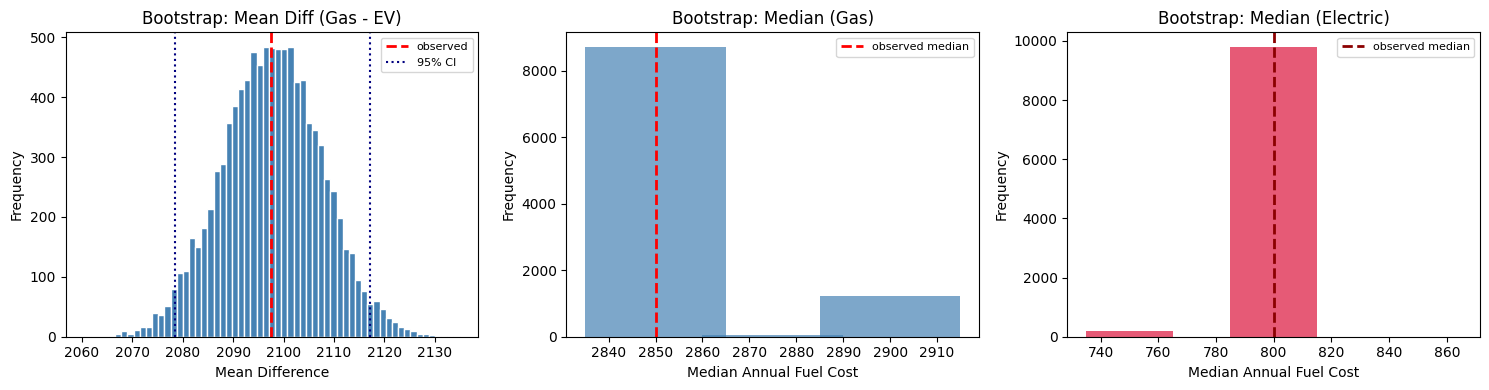

In [18]:
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

# Create figure and subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))


axes[0].hist(
    boot_mean_diffs,
    bins='auto',
    color='steelblue',
    edgecolor='white'
)

axes[0].axvline(
    obs_diff,
    color='red',
    linestyle='dashed',
    linewidth=2,
    label='observed'
)

axes[0].axvline(
    ci_mean[0],
    color='navy',
    linestyle=':',
    linewidth=1.5,
    label='95% CI'
)

axes[0].axvline(
    ci_mean[1],
    color='navy',
    linestyle=':',
    linewidth=1.5
)

axes[0].set_title('Bootstrap: Mean Diff (Gas - EV)')
axes[0].set_xlabel('Mean Difference')
axes[0].set_ylabel('Frequency')
axes[0].legend(fontsize=8)


gas_counts = Counter(boot_med_gas)

axes[1].bar(
    gas_counts.keys(),
    gas_counts.values(),
    width=30,
    color='steelblue',
    alpha=0.7
)

axes[1].axvline(
    np.median(gas),
    color='red',
    linestyle='dashed',
    linewidth=2,
    label='observed median'
)

axes[1].set_title('Bootstrap: Median (Gas)')
axes[1].set_xlabel('Median Annual Fuel Cost')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=8)


ev_counts = Counter(boot_med_ev)

axes[2].bar(
    ev_counts.keys(),
    ev_counts.values(),
    width=30,
    color='crimson',
    alpha=0.7
)

axes[2].axvline(
    np.median(ev),
    color='darkred',
    linestyle='dashed',
    linewidth=2,
    label='observed median'
)

axes[2].set_title('Bootstrap: Median (Electric)')
axes[2].set_xlabel('Median Annual Fuel Cost')
axes[2].set_ylabel('Frequency')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

# 6. Final Analysis

In [19]:
print('RESULTS SUMMARY')
print(f'observed difference (gas - EV): ${obs_diff:,.2f}/year')
p_str = '< 0.001' if p_value == 0 else f'{p_value:.4f}'
print(f'p-value: {p_str}')
if p_value < 0.05:
    print('-> reject null, gas costs significantly more')

print()
print(f'bootstrap CI (mean diff): ${ci_mean[0]:,.2f} to ${ci_mean[1]:,.2f}')
print(f'median gas: ${np.median(gas):,.2f}, (95% CI: ${ci_med_gas[0]:,.2f} - ${ci_med_gas[1]:,.2f})')
print(f'median EV:  ${np.median(ev):,.2f}, (95% CI: ${ci_med_ev[0]:,.2f} - ${ci_med_ev[1]:,.2f})')

RESULTS SUMMARY
observed difference (gas - EV): $2,097.51/year
p-value: < 0.001
-> reject null, gas costs significantly more

bootstrap CI (mean diff): $2,078.55 to $2,117.06
median gas: $2,850.00, (95% CI: $2,850.00 - $2,900.00)
median EV:  $800.00, (95% CI: $800.00 - $800.00)


## 7. Mapping to the Only One Test Framework

| Element | In this example |
|---|---|
| **Data** | EPA FuelEconomy.gov `vehicles.csv`, filtered to 2015–2024 model years, Electricity and Gasoline fuel types only. Each row is one vehicle configuration. |
| **Test statistic** | Mean annual fuel cost of gas vehicles minus mean annual fuel cost of EVs. |
| **Observed value** | $2,097.51/year  |
| **Null hypothesis** | Fuel type has no effect on annual cost. Shuffling the Electric/Gas labels should produce differences as large as the observed one fairly often. |
| **How you simulate under the null** | Randomly shuffle the `fuel_category` labels 10,000 times and recompute mean difference each time |
| **Reference distribution** | 10,000 simulated mean differences, centered near zero |
| **p-value** | Fraction of simulated differences >= obserrvsed difference |

---

## 8. Limitations

- fuel costs are EPA estimates assuming 15,000 miles/year and prices from the label year - actual costs vary a lot by driver and where you live
- gas prices changed a lot 2015-2024, so older model years probably show a smaller gap than more recent ones
- this is only fuel cost, not total cost of ownership - EVs have higher sticker prices and lower maintenance costs so the full picture is more complicated
- way more gas vehicles in the dataset than EVs, especially trucks, so the EV estimates at the class level are noisier
- doesnt account for home charger installation costs for EV owners
